In [21]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [11]:
X = pd.read_csv('../../data/processed/normalized_best_features.csv', index_col=0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
df_engineered = pd.read_csv('../../data/processed/normalized_best_features.csv')
df_meta = pd.read_csv('../../data/processed/meta_best.csv')
df_with_clusters = df_meta.join(df_engineered)

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

gmm_final = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=10
)

cluster_labels = gmm_final.fit_predict(X_pca)
cluster_probs = gmm_final.predict_proba(X_pca)
df_with_clusters["role_cluster"] = cluster_labels

for k in range(gmm_final.n_components):
    df_with_clusters[f"cluster_{k}_prob"] = cluster_probs[:, k]

In [14]:
for c in sorted(df_with_clusters["role_cluster"].unique()):
    print(f"\n=== Cluster {c}: Top 10 by CA ===")
    display(
        df_with_clusters[df_with_clusters["role_cluster"] == c]
        [["Name","Club","CA","PA"]]
        .sort_values(by="CA", ascending=False)
        .head(10)
    )


=== Cluster 0: Top 10 by CA ===


,Name,Club,CA,PA
0,Harry Kane,FC Bayern,184,185
9,Martin Ødegaard,Arsenal,173,180
5,Luka Modrić,R. Madrid,171,180
7,Bruno Fernandes,Man UFC,171,174
3,Leroy Sané,FC Bayern,169,172
14,İlkay Gündoğan,Barcelona,167,167
15,Frenkie de Jong,Barcelona,165,181
10,Thiago,Liverpool,163,173
25,Christopher Nkunku,Chelsea,162,172
28,Trent Alexander-Arnold,Liverpool,162,174



=== Cluster 1: Top 10 by CA ===


,Name,Club,CA,PA
6,Declan Rice,Arsenal,176,182
8,Eduardo Camavinga,R. Madrid,170,180
31,Reece James,Chelsea,161,170
16,Casemiro,Man UFC,157,170
18,Leon Goretzka,FC Bayern,157,170
24,Aurélien Tchouameni,R. Madrid,157,177
22,Adrien Rabiot,Juventus,156,159
173,Lisandro Martínez,Man UFC,155,165
82,Benjamin White,Arsenal,155,162
77,João Palhinha,Fulham,155,164



=== Cluster 2: Top 10 by CA ===


,Name,Club,CA,PA
1,Jude Bellingham,R. Madrid,177,188
2,Joshua Kimmich,FC Bayern,174,183
11,Federico Valverde,R. Madrid,168,175
27,Bruno Guimarães,Newcastle,165,170
4,Nicolò Barella,Inter,161,169
20,David Alaba,R. Madrid,159,174
136,Yves Bissouma,Tottenham,157,165
38,Sandro Tonali,Newcastle,157,171
26,Koke,A. Madrid,157,162
34,Mason Mount,Man UFC,156,170


In [16]:
def summarize_clusters(df_k, feature_cols):
    print("\n=== Cluster sizes ===")
    print(df_k["cluster"].value_counts().sort_index())
    
    print("\n=== Age / CA / PA by cluster ===")
    print(df_k.groupby("cluster")[["Age","CA","PA"]].mean().round(2))
summarize_clusters(df_with_clusters.rename(columns={"role_cluster":"cluster"}), X.columns.tolist())


=== Cluster sizes ===
cluster
0    251
1    212
2    220
Name: count, dtype: int64

=== Age / CA / PA by cluster ===
           Age      CA      PA
cluster                       
0        25.23  137.62  151.87
1        26.58  135.08  146.04
2        25.12  134.70  148.70


In [18]:
def cluster_attribute_profiles(df_k, feature_cols):
    scaler_attr = StandardScaler()
    Z = scaler_attr.fit_transform(df_k[feature_cols].values)
    df_z = pd.DataFrame(Z, columns=feature_cols, index=df_k.index)
    df_z["cluster"] = df_k["cluster"].values

    cluster_means = df_z.groupby("cluster")[feature_cols].mean().round(3)
    return cluster_means

def print_top_attributes_per_cluster(cluster_means, top_n=8):
    for c in cluster_means.index:
        print(f"\n=== Cluster {c}: top {top_n} attributes (z-score) ===")
        s = cluster_means.loc[c].sort_values(ascending=False)
        print(s.head(top_n))
        print("\n--- lowest attributes ---")
        print(s.tail(top_n))

cluster_means = cluster_attribute_profiles(
    df_with_clusters.rename(columns={"role_cluster":"cluster"}),
    X.columns.tolist()
)
print_top_attributes_per_cluster(cluster_means, top_n=8)


=== Cluster 0: top 8 attributes (z-score) ===
Fla    0.823
Tec    0.821
Cor    0.811
Fre    0.801
Fir    0.782
Dri    0.770
Cro    0.736
Vis    0.709
Name: 0, dtype: float64

--- lowest attributes ---
Tea   -0.590
Agg   -0.618
Wor   -0.627
Str   -0.683
Bra   -0.800
Pos   -0.842
Mar   -0.869
Tck   -0.923
Name: 0, dtype: float64

=== Cluster 1: top 8 attributes (z-score) ===
Mar    0.946
Tck    0.869
Bra    0.818
Hea    0.788
Str    0.772
Pos    0.765
Jum    0.676
Agg    0.613
Name: 1, dtype: float64

--- lowest attributes ---
Pas   -0.758
Dri   -0.798
Fre   -0.807
Vis   -0.842
Cor   -0.860
Fla   -0.896
Fir   -0.901
Tec   -0.998
Name: 1, dtype: float64

=== Cluster 2: top 8 attributes (z-score) ===
Pos    0.223
Sta    0.222
Tck    0.215
Wor    0.210
Tea    0.175
Pas    0.153
Bra    0.124
Agg    0.114
Name: 2, dtype: float64

--- lowest attributes ---
Cor    -0.097
Hea    -0.098
Dri    -0.109
Fin    -0.120
Pen    -0.129
Fre    -0.135
Cro    -0.154
L Th   -0.208
Name: 2, dtype: float64


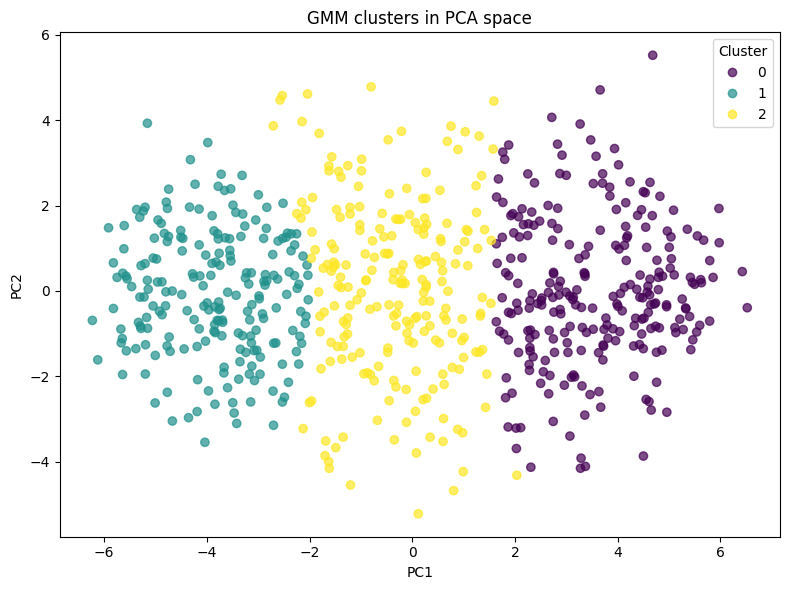

In [19]:
def plot_pca_scatter(X_pca, df_k):
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=df_k["cluster"],
        alpha=0.7
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("GMM clusters in PCA space")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()
plot_pca_scatter(X_pca, df_with_clusters.rename(columns={"role_cluster":"cluster"}))

In [20]:
radar_attrs = [
    "Pas",   # passing
    "Tec",   # technique
    "Vis",   # vision
    "Dri",   # dribbling
    "Fir",   # first touch
    
    "Tck",   # tackling
    "Mar",   # marking
    "Pos",   # positioning
    "Agg",   # aggression
    "Bra",   # bravery
    
    "Sta",   # stamina
    "Pac",   # pace
    "Wor",   # work rate
    "Ant",   # anticipation
    "Dec",   # decisions
]

def plot_radar(cluster_means, radar_attrs, cluster_id):
    values = cluster_means.loc[cluster_id, radar_attrs].values
    labels = radar_attrs


    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
    values = np.concatenate((values, [values[0]]))
    angles = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    colors = ["#FF6B6B", "#4ECDC4", "#1A535C", "#FFE66D", "#FF9F1C"]
    color = colors[cluster_id % len(colors)]
    
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels([])

    plt.title(f"Cluster {cluster_id} — Role Profile", size=14, pad=20)
    plt.show()

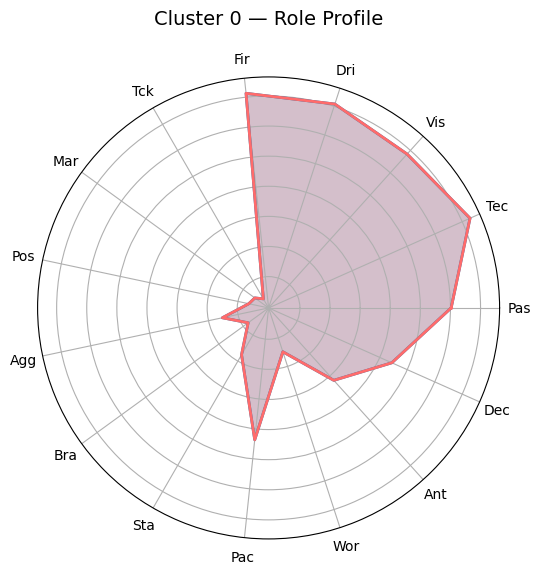

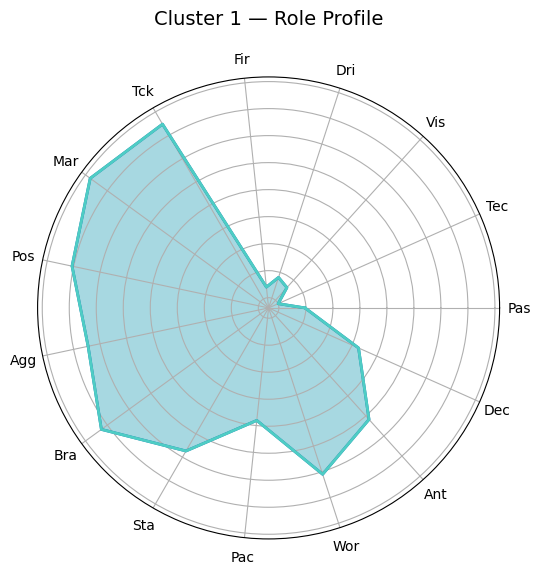

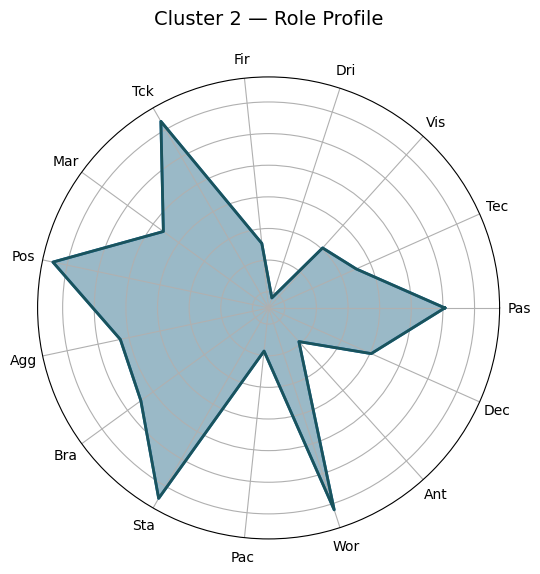

In [22]:
for c in cluster_means.index:
    plot_radar(cluster_means, radar_attrs, c)